In [1]:
# Model training notebook - K-Means clustering

In [2]:
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")

DATA_PATH = "Data/Mall_Customers_cleaned.csv"
FEATURES = ["Age", "Annual_Income", "Spending_Score"]

In [3]:
# load cleaned data
df = pd.read_csv(DATA_PATH)
df.head()

,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [4]:
# scale features
X = df[FEATURES]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pd.DataFrame(X_scaled, columns=FEATURES).describe().round(2)

,Age,Annual_Income,Spending_Score
count,200.00,200.00,200.00
mean,-0.00,-0.00,-0.00
std,1.00,1.00,1.00
min,-1.50,-1.74,-1.91
25%,-0.72,-0.73,-0.60
50%,-0.20,0.04,-0.01
75%,0.73,0.67,0.89
max,2.24,2.92,1.89


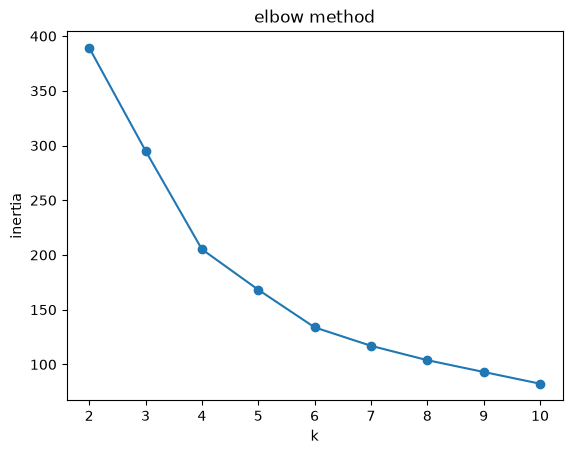

In [5]:
# elbow method
inertias = []
K_LIST = range(2, 11)

for k in K_LIST:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    model.fit(X_scaled)
    inertias.append(model.inertia_)

plt.plot(K_LIST, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("inertia")
plt.title("elbow method")
plt.show()

In [6]:
# silhouette score
scores = []
for k in K_LIST:
    model = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = model.fit_predict(X_scaled)
    scores.append(silhouette_score(X_scaled, labels))

score_df = pd.DataFrame({"k": list(K_LIST), "silhouette": scores})
score_df

,k,silhouette
0,2,0.335472
1,3,0.357793
2,4,0.403958
3,5,0.416643
4,6,0.428417
5,7,0.417232
6,8,0.408207
7,9,0.417693
8,10,0.406554


In [7]:
# train final model
filtered = score_df[(score_df["k"] >= 4) & (score_df["k"] <= 7)]
OPTIMAL_K = int(filtered.loc[filtered["silhouette"].idxmax(), "k"])
print("selected k:", OPTIMAL_K)

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=42, n_init=10)
df["Cluster"] = kmeans.fit_predict(X_scaled)
print("silhouette:", round(silhouette_score(X_scaled, df["Cluster"]), 4))

selected k: 6
silhouette: 0.4284


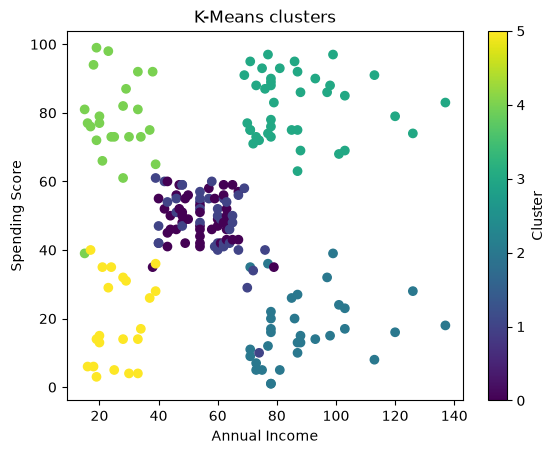

In [8]:
# cluster plot
plt.scatter(df["Annual_Income"], df["Spending_Score"], c=df["Cluster"], cmap="viridis")
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("K-Means clusters")
plt.colorbar(label="Cluster")
plt.show()

In [9]:
# cluster averages
df.groupby("Cluster")[FEATURES].mean().round(2)

,Age,Annual_Income,Spending_Score
Cluster,,,
0,56.33,54.27,49.07
1,26.79,57.10,48.13
2,41.94,88.94,16.97
3,32.69,86.54,82.13
4,25.00,25.26,77.61
5,45.52,26.29,19.38


In [10]:
# for saved pipeline artifacts run:
# python src/Pipeline/train_pipeline.py